# 1. pysam и pyBigWig: читаем bam и bw

**Цель:** научиться программно открывать RNAseq bam, смотреть риды, флаги, MAPQ, CIGAR и считать покрытие. В конце посмотрим тот же регион в bw

**Входные файлы:**

- RNAseq BAM + BAI из day2
- RNA-eq bigWig из day2

**Библиотеки:** `pysam`, `pyBigWig`, `pandas`, `numpy`, `matplotlib`, `seaborn`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pysam
import pyBigWig

sns.set_theme(style="whitegrid")

### Пути к файлам

Берем bam и bw, которые получили в RNAseq практике

In [4]:
bam_path = Path("../../day2_RNA_practice/results/star/rnaseq/MoPh7.rnaseq.STAR.q30.bam")
bam_index = Path(str(bam_path) + ".bai")
bigwig_path = Path("../../day2_RNA_practice/results/tracks/rnaseq/MoPh7.rnaseq.STAR.bw")

In [5]:
bam = pysam.AlignmentFile(bam_path, "rb")

print("Number of chromosomes:", len(bam.references))
print("Mapped reads:", bam.mapped)
print("Unmapped reads:", bam.unmapped)
print("First chromosomes:", bam.references[:5])

Number of chromosomes: 24
Mapped reads: 43809008
Unmapped reads: 0
First chromosomes: ('chr1', 'chr2', 'chr3', 'chr4', 'chr5')


In [6]:
chrom_table = pd.DataFrame({
    "chrom": bam.references,
    "length": bam.lengths,
})

chrom_table.head()

,chrom,length
0,chr1,248387328
1,chr2,242696752
2,chr3,201105948
3,chr4,193574945
4,chr5,182045439


### Смотрим один read

`bam.fetch(chrom, start, end)` возвращает reads, которые попали в заданный регион

In [7]:
chrom = "chr1"
start = 1_000_000
end = 1_010_000

for read in bam.fetch(chrom, start, end):
    print("query_name:", read.query_name)
    print("reference_name:", read.reference_name)
    print("reference_start:", read.reference_start)
    print("reference_end:", read.reference_end)
    print("mapping_quality:", read.mapping_quality)
    print("cigarstring:", read.cigarstring)
    print("is_paired:", read.is_paired)
    print("is_reverse:", read.is_reverse)
    print("is_duplicate:", read.is_duplicate)
    print("tags:", read.tags[:5])
    break

query_name: E250181306L1C014R00902385517
reference_name: chr1
reference_start: 919644
reference_end: 1237736
mapping_quality: 255
cigarstring: 31M610N57M317382N12M
is_paired: True
is_reverse: True
is_duplicate: False
tags: [('NH', 1), ('HI', 1), ('AS', 187), ('nM', 0), ('RG', 'MoPh7_rnaseq')]


Основные атрибуты read:

- `query_name` — имя read
- `reference_name`, `reference_start`, `reference_end` — куда read выровнялся
- `mapping_quality` — уверенность выравнивания
- `cigarstring` — как read лег на референс
- `is_paired`, `is_read1`, `is_read2` — paired-end информация
- `is_reverse` — strand
- `is_unmapped`, `mate_is_unmapped`
- `is_duplicate`
- `is_secondary`, `is_supplementary`
- `template_length`
- `query_qualities`
- `tags`

In [8]:
def is_good_read(read, min_mapq=30):
    return (
        not read.is_unmapped
        and not read.is_secondary
        and not read.is_supplementary
        and not read.is_duplicate
        and read.mapping_quality >= min_mapq
    )

In [9]:
reads = list(bam.fetch(chrom, start, end))

summary = {
    "total_reads": len(reads),
    "mapped": sum(not r.is_unmapped for r in reads),
    "MAPQ >= 30": sum(r.mapping_quality >= 30 for r in reads),
    "duplicate": sum(r.is_duplicate for r in reads),
    "secondary_or_supplementary": sum(r.is_secondary or r.is_supplementary for r in reads),
    "good_reads": sum(is_good_read(r) for r in reads),
}

read_summary = pd.DataFrame(summary.items(), columns=["category", "count"])
read_summary

,category,count
0,total_reads,932
1,mapped,932
2,MAPQ >= 30,932
3,duplicate,0
4,secondary_or_supplementary,0
5,good_reads,932


### Покрытие из bam

`count_coverage()` считает количество A/C/G/T, которые покрывают каждую позицию

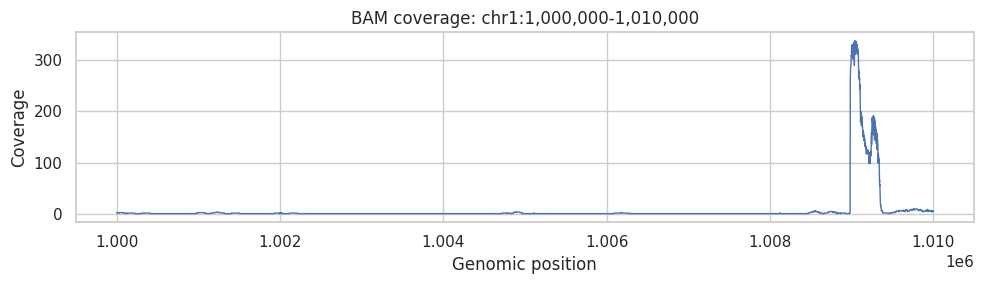

In [11]:
A, C, G, T = bam.count_coverage(chrom, start, end)
coverage = np.array(A) + np.array(C) + np.array(G) + np.array(T)
positions = np.arange(start, end)

plt.figure(figsize=(10, 3))
plt.plot(positions, coverage, linewidth=1)
plt.title(f"BAM coverage: {chrom}:{start:,}-{end:,}")
plt.xlabel("Genomic position")
plt.ylabel("Coverage")
plt.tight_layout()
plt.show()

### Сплайсированные риды

В RNA-seq CIGAR может содержать `N`: это сплайс регионы на референсе (интроны)

Коротко

- `M` — alignment match
- `N` — skipped region, intron in RNA-seq
- `I` — insertion
- `D` — deletion
- `S` — soft clipping

In [12]:
def has_splice(read):
    return "N" in read.cigarstring if read.cigarstring else False

spliced_reads = [r for r in reads if has_splice(r)]
print("Reads in region:", len(reads))
print("Spliced reads:", len(spliced_reads))
print("Fraction spliced:", len(spliced_reads) / len(reads) if reads else np.nan)

for read in spliced_reads[:5]:
    print(read.query_name, read.cigarstring)

Reads in region: 932
Spliced reads: 222
Fraction spliced: 0.23819742489270387
E250181306L1C014R00902385517 31M610N57M317382N12M
E250181306L1C006R01900641796 11M258237N88M1S
E250181306L1C013R00800683518 11M286407N64M9220N25M
E250181306L1C015R01002885726 11M286407N64M9220N25M
E250181306L1C018R02502511067 63M30492N37M


### Работа с bw через pyBigWig

In [13]:
bw = pyBigWig.open(str(bigwig_path))

print("Number of chromosomes:", len(bw.chroms()))
print("chr1 length:", bw.chroms().get("chr1"))
print("Mean signal:", bw.stats(chrom, start, end, type="mean")[0])

Number of chromosomes: 24
chr1 length: 248387328
Mean signal: 26.471149292318156


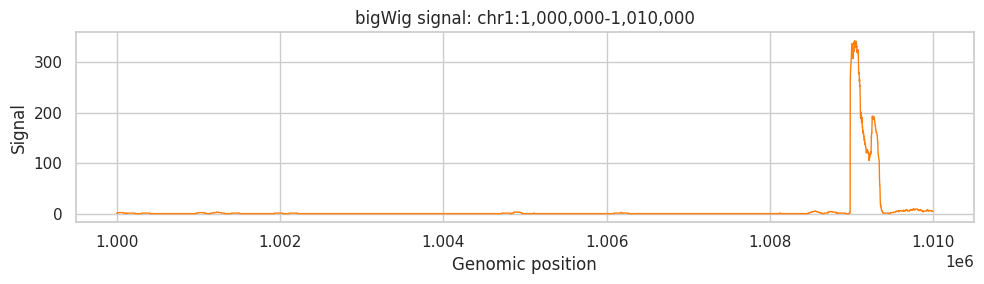

In [14]:
signal = np.array(bw.values(chrom, start, end))
signal = np.nan_to_num(signal, nan=0)

plt.figure(figsize=(10, 3))
plt.plot(positions, signal, color="tab:orange", linewidth=1)
plt.title(f"bigWig signal: {chrom}:{start:,}-{end:,}")
plt.xlabel("Genomic position")
plt.ylabel("Signal")
plt.tight_layout()
plt.show()

bw.close()
bam.close()